<div style = "font-size: 52px; color: #3B82F6">Polynomial Regression</div>
<div style = "font-size: 14px; color: #9497a1;">การถดถอยเชิงพหุคณิต</div>

<div style = "font-size: 36px;">Import Library</div>
<div style = "font-size: 14px; color: #9497a1;">นำเข้าไลบรารีต่างๆ</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

<div style = "font-size: 36px;">Data preprocessing & Data cleansing & Handling Missing Values</div>
<div style = "font-size: 14px; color: #9497a1;">เตรียมข้อมูล ทำความสะอาดข้อมูล และจัดการค่าที่หายไป</div>

In [2]:
data = pd.read_csv("C:\\Users\\vachi\\OneDrive\\Desktop\\codingSKT\\dataset.csv")

data = data.drop(columns = ["gen", "code", "robot_5", "project_2", "project_3", "project_4", "project_5", "project_6", "career_5", "career_6"])
data = data.drop(0)

data = data.replace("-", pd.NA)
data.fillna(0, inplace = True)

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors = "coerce")

<div style = "font-size: 36px;">Define Feature & Label</div>
<div style = "font-size: 14px; color: #9497a1;">กำหนด Feature และ Label</div>

In [3]:
X1 = ["thai_1", "english_basic_1", "english_add_1", "math_basic_1", "math_add_1", "science_1", "physics_1", "chemistry_1", "biology_1", "computer_1", "robot_1", "project_1", "social1_1", "social2_1", "health_1", "pe_1", "art_1", "career_1", "credits_studied_1", "credits_earned_1"]
X2 = ["thai_2", "english_basic_2", "english_add_2", "math_basic_2", "math_add_2", "science_2", "physics_2", "chemistry_2", "biology_2", "computer_2", "robot_2", "social1_2", "social2_2", "health_2", "pe_2", "art_2", "career_2", "credits_studied_2", "credits_earned_2"]
X3 = ["thai_3", "english_basic_3", "english_add_3", "math_basic_3", "math_add_3", "science_3", "physics_3", "chemistry_3", "biology_3", "computer_3", "robot_3", "social1_3", "social2_3", "health_3", "pe_3", "art_3", "career_3", "credits_studied_3", "credits_earned_3"]
X4 = ["thai_4", "english_basic_4", "english_add_4", "math_basic_4", "math_add_4", "science_4", "physics_4", "chemistry_4", "biology_4", "computer_4", "robot_4", "social1_4", "social2_4", "health_4", "pe_4", "art_4", "career_4", "credits_studied_4", "credits_earned_4"]
X5 = ["thai_5", "english_basic_5", "english_add_5", "math_basic_5", "math_add_5", "science_5", "physics_5", "chemistry_5", "biology_5", "computer_5", "social1_5", "social2_5", "health_5", "pe_5", "art_5", "credits_studied_5", "credits_earned_5"]
X6 = ["thai_6", "english_basic_6", "english_add_6", "math_basic_6", "math_add_6", "science_6", "physics_6", "chemistry_6", "biology_6", "computer_6", "robot_6", "social1_6", "social2_6", "health_6", "pe_6", "art_6", "credits_studied_6", "credits_earned_6"]

y1 = "gpa_1"
y2 = "gpa_2"
y3 = "gpa_3"
y4 = "gpa_4"
y5 = "gpa_5"
y6 = "gpa_6"

X_array = [X1, X2, X3, X4, X5, X6]
y_array = [y1, y2, y3, y4, y5, y6]

<div style = "font-size: 36px;">Train-Test Split</div>
<div style = "font-size: 14px; color: #9497a1;">แบ่ง Train และ Test</div>

In [4]:
random_state_array = [42, 42, 42, 45, 42, 42]
X_train_array = []
X_test_array = []
y_train_array = []
y_test_array = []

for i in range(len(X_array)):
    X_train, X_test, y_train, y_test = train_test_split(data[X_array[i]], data[y_array[i]], test_size = 0.2, random_state = random_state_array[i])

    X_train = X_train.apply(pd.to_numeric, errors = "coerce").fillna(0)
    X_test = X_test.apply(pd.to_numeric, errors = "coerce").fillna(0)
    y_train = y_train.apply(pd.to_numeric, errors = "coerce").fillna(0)
    y_test = y_test.apply(pd.to_numeric, errors = "coerce").fillna(0)

    X_train_array.append(X_train)
    X_test_array.append(X_test)
    y_train_array.append(y_train)
    y_test_array.append(y_test)

<div style = "font-size: 36px;">Model Training</div>
<div style = "font-size: 14px; color: #9497a1;">สร้างและฝึกโมเดล</div>

In [5]:
modelArray = []

for i in range(len(X_array)):
    model = make_pipeline(PolynomialFeatures(degree = 2), LinearRegression())
    model.fit(X_train_array[i], y_train_array[i])
    modelArray.append(model)

<div style = "font-size: 36px;">Model Prediction</div>
<div style = "font-size: 14px; color: #9497a1;">ทำนายผล</div>

In [6]:
y_preds = []

for i in range(len(modelArray)):
    y_pred = modelArray[i].predict(X_test_array[i])
    y_preds.append(y_pred)

<div style = "font-size: 36px;">Model Evaluation</div>
<div style = "font-size: 14px; color: #9497a1;">ประเมินผลโมเดล</div>

In [7]:
for i in range(len(modelArray)):
    r2 = r2_score(y_test_array[i], y_preds[i])
    mse = mean_squared_error(y_test_array[i], y_preds[i])

    print(f"GPA {i + 1}:\n\tR² = {r2}\n\tMSE = {mse}\n")

GPA 1:
	R² = 0.9975293479626919
	MSE = 0.00046826020997897693

GPA 2:
	R² = 0.9940005188628118
	MSE = 0.0015303041522357248

GPA 3:
	R² = 0.9930737441758088
	MSE = 0.020842108082085756

GPA 4:
	R² = 0.9995411567206014
	MSE = 0.0012900574955793081

GPA 5:
	R² = 0.999985462461866
	MSE = 3.375637797570558e-05

GPA 6:
	R² = 0.9999950611126266
	MSE = 1.0852280196504517e-05



<div style = "font-size: 36px;">Polynomial Regression Graph</div>
<div style = "font-size: 14px; color: #9497a1;">กราฟของโมเดลแบบ Polynomial Regression</div>

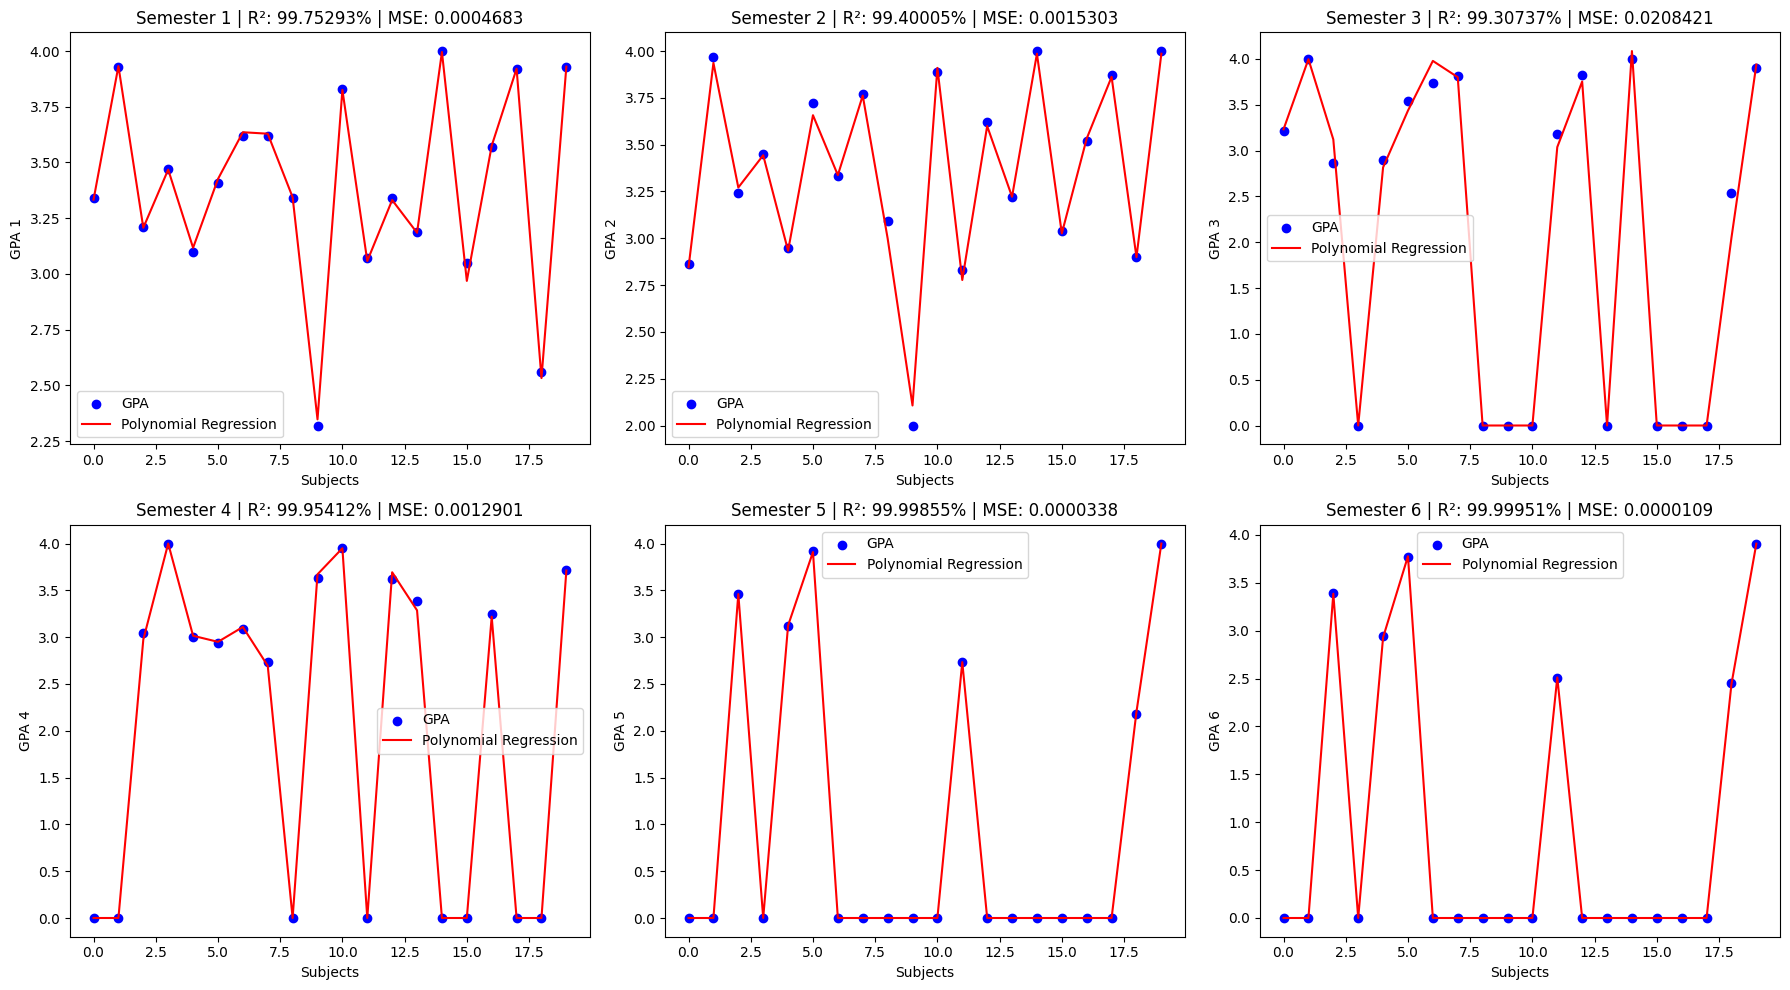

In [8]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes = axes.flatten()

for i in range(len(modelArray)):
    ax = axes[i]
    ax.scatter(range(len(y_test_array[i])), y_test_array[i], color = "blue", label = "GPA")
    ax.plot(range(len(y_test_array[i])), y_preds[i], color = "red", label = "Polynomial Regression")
    ax.set_title(f"Semester {i + 1} | R²: {r2_score(y_test_array[i], y_preds[i]) * 100:.5f}% | MSE: {mean_squared_error(y_test_array[i], y_preds[i]):.7f}")
    ax.set_xlabel("Subjects")
    ax.set_ylabel(f"GPA {i + 1}")
    ax.legend()

plt.tight_layout()
plt.show()